In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 10

def thin_xticks(ax, labels, every=3, rotation=45):
   
    positions = range(0, len(labels), every)
    ax.set_xticks(list(positions))
    ax.set_xticklabels([labels[i] for i in positions], rotation=rotation, ha="right")

df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")


df["Order Date"] = pd.to_datetime(df["Order Date"], format="%m/%d/%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%m/%d/%Y")
df = df.drop_duplicates()
df = df.dropna(subset=["Sales", "Profit", "Discount"])

print(df.shape)
df.head()

(9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


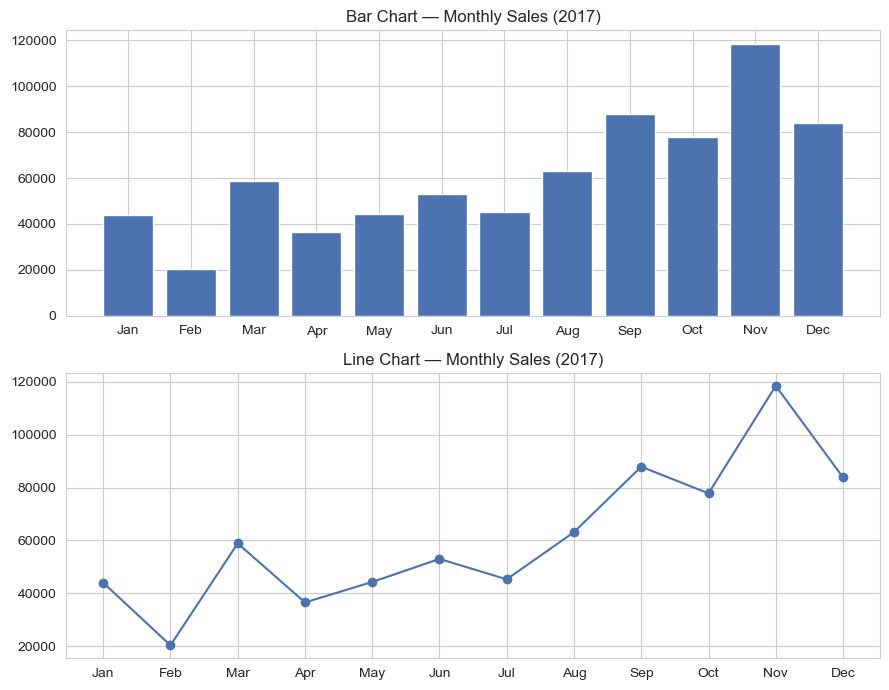

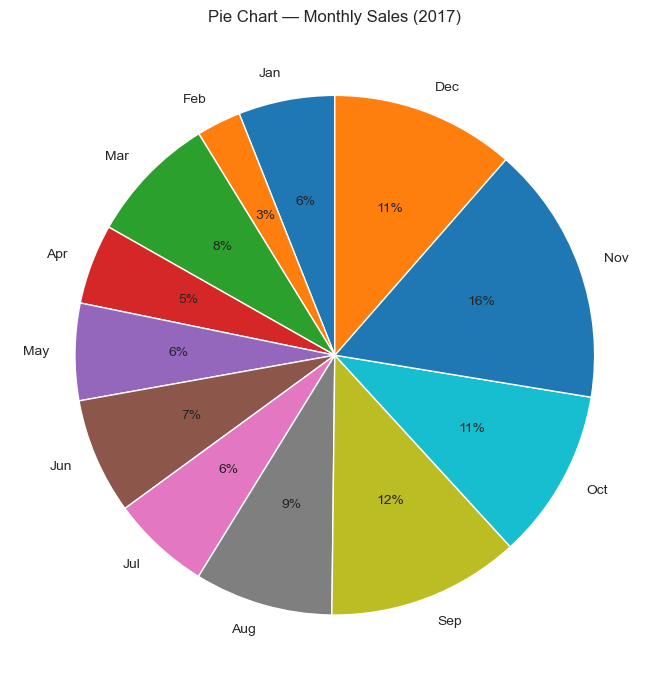

In [4]:
#task 1 
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month_name().str[:3]  # Jan, Feb, ...

year_data = df[df["Year"] == 2017]   # last full year in the data
month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
monthly_sales = (year_data.groupby("Month")["Sales"].sum()
                  .reindex(month_order).reset_index())
months = monthly_sales["Month"].tolist()

fig, axes = plt.subplots(2, 1, figsize=(9, 7))
axes[0].bar(months, monthly_sales["Sales"], color="#4C72B0")
axes[0].set_title("Bar Chart — Monthly Sales (2017)")
axes[1].plot(months, monthly_sales["Sales"], marker="o", color="#4C72B0")
axes[1].set_title("Line Chart — Monthly Sales (2017)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 7))
plt.pie(monthly_sales["Sales"], labels=months, autopct="%1.0f%%", startangle=90)
plt.title("Pie Chart — Monthly Sales (2017)")
plt.tight_layout()
plt.show()

**Which chart shows the trend best, and which one hides it? Why?**

The **line chart** shows the trend best because monthly sales is a continuous time
series — the connected points let the eye immediately see rises, dips, and overall
direction across 48 months. The **pie chart hides the trend completely**: it has 48
slices, order-over-time has no meaning in a pie (it's arranged in a circle, not a
timeline), and slices that close in size are impossible to compare precisely. The bar
chart is usable but with 48 categories it becomes cluttered — good for exact
month-to-month comparison, not for reading a trend at a glance.

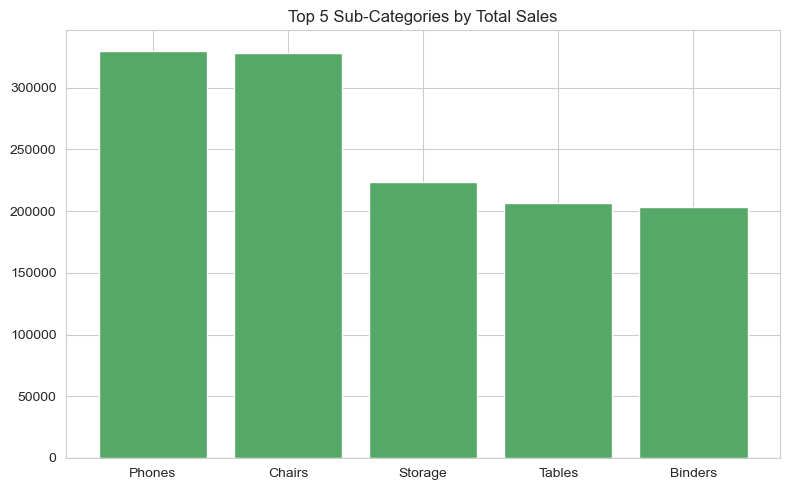

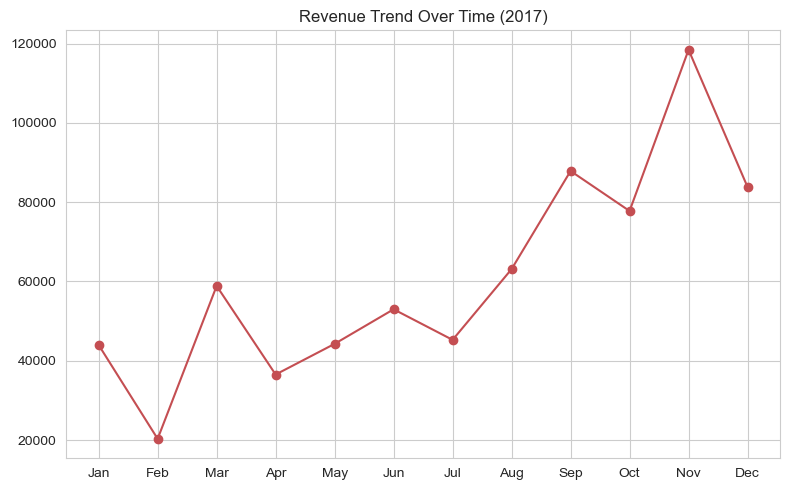

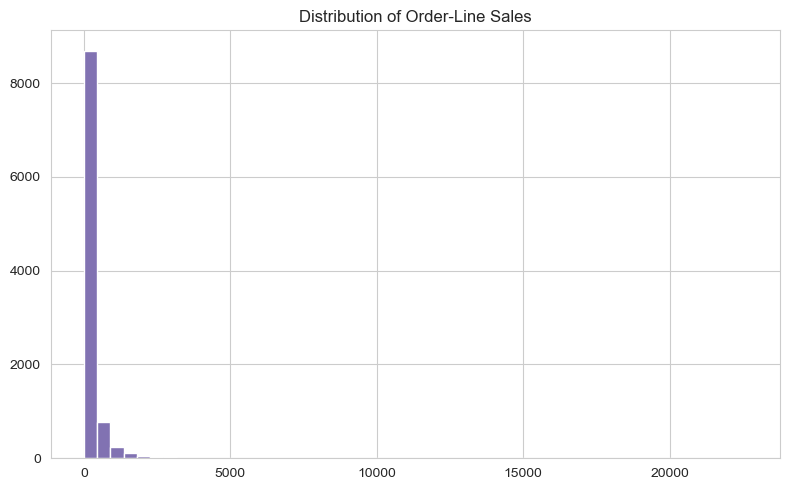

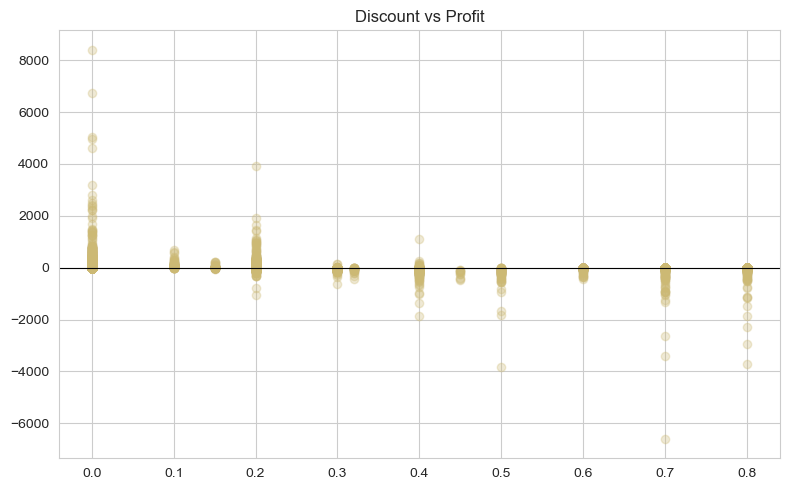

In [11]:
# 2.1 Top 5 sub-categories -> Bar chart
top5 = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False).head(5)
plt.figure()
plt.bar(top5.index, top5.values, color="#55A868")
plt.title("Top 5 Sub-Categories by Total Sales")
plt.tight_layout(); plt.show()

# 2.2 Revenue trend -> Line chart (reuses Task 1's 2017 monthly_sales)
plt.figure()
plt.plot(months, monthly_sales["Sales"], marker="o", color="#C44E52")
plt.title("Revenue Trend Over Time (2017)")
plt.tight_layout(); plt.show()

# 2.3 Distribution of order-line sales -> Histogram
plt.figure()
plt.hist(df["Sales"], bins=50, color="#8172B2")
plt.title("Distribution of Order-Line Sales")
plt.tight_layout(); plt.show()

# 2.4 Discount vs Profit -> Scatter plot
plt.figure()
plt.scatter(df["Discount"], df["Profit"], alpha=0.3, color="#CCB974")
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Discount vs Profit")
plt.tight_layout(); plt.show()

*Justification:* A bar chart lets you compare 5 discrete magnitudes by reading
bar heights precisely. A **pie chart** would be the weak choice — with 5 similarly-sized
slices, angle comparison is much harder for the eye than comparing bar heights.

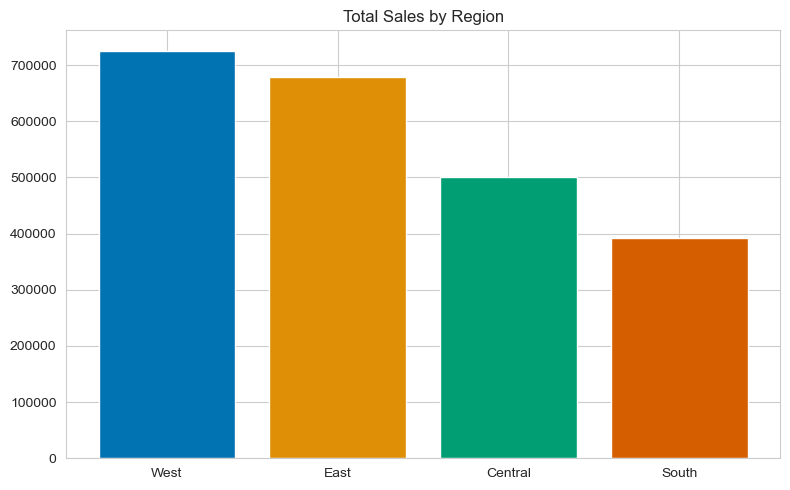

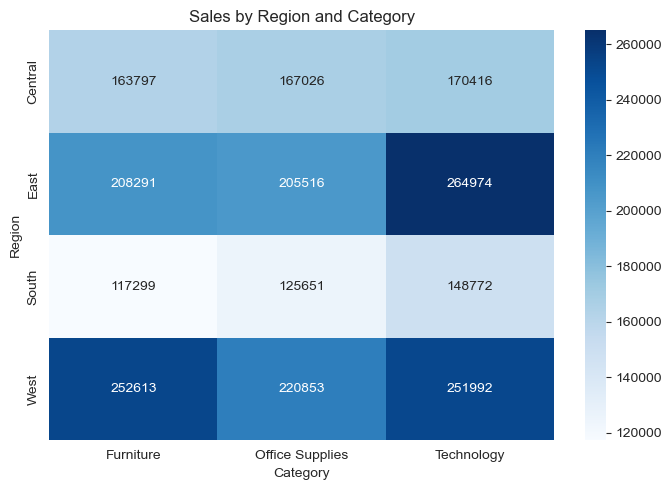

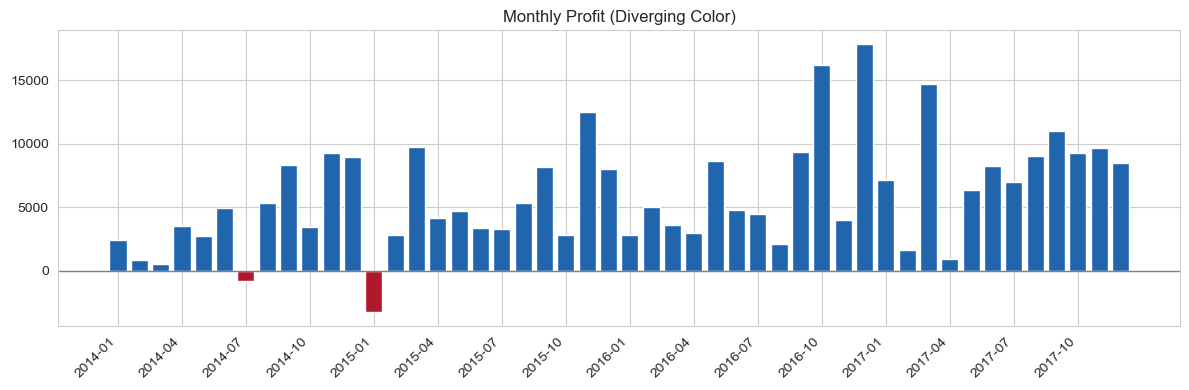

In [6]:
# 3a 
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
categorical_colors = sns.color_palette("colorblind", n_colors=len(region_sales))
plt.figure()
plt.bar(region_sales.index, region_sales.values, color=categorical_colors)
plt.title("Total Sales by Region")
plt.tight_layout(); plt.show()

# 3b 
region_category = df.pivot_table(index="Region", columns="Category", values="Sales", aggfunc="sum")
plt.figure(figsize=(7, 5))
sns.heatmap(region_category, annot=True, fmt=".0f", cmap="Blues")
plt.title("Sales by Region and Category")
plt.tight_layout(); plt.show()

# 3c 
monthly_profit = df.groupby(df["Order Date"].dt.to_period("M").astype(str))["Profit"].sum().reset_index()
monthly_profit.columns = ["Month", "Profit"]
colors = ["#B2182B" if v < 0 else "#2166AC" for v in monthly_profit["Profit"]]
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(monthly_profit["Month"], monthly_profit["Profit"], color=colors)
ax.axhline(0, color="gray", linewidth=1)
ax.set_xticks(range(0, len(monthly_profit), 3))
ax.set_xticklabels(monthly_profit["Month"][::3], rotation=45, ha="right")
plt.title("Monthly Profit (Diverging Color)")
plt.tight_layout(); plt.show()

In [14]:
# WCAG contrast ratio 
def contrast_ratio(rgb1, rgb2):
    def luminance(rgb):
        r, g, b = [c / 255 for c in rgb]
        r, g, b = [c / 12.92 if c <= 0.03928 else ((c + 0.055) / 1.055) ** 2.4
                    for c in (r, g, b)]
        return 0.2126 * r + 0.7152 * g + 0.0722 * b
    L1, L2 = luminance(rgb1), luminance(rgb2)
    lighter, darker = max(L1, L2), min(L1, L2)
    return (lighter + 0.05) / (darker + 0.05)

white = (255, 255, 255)
colors = {
    "Loss red":  (178, 24, 43),
    "Gain blue": (33, 102, 172),
}
for name, rgb in colors.items():
    ratio = contrast_ratio(rgb, white)
    print(name, round(ratio, 2), "PASS" if ratio >= 4.5 else "FAIL")

Loss red 6.87 PASS
Gain blue 5.9 PASS


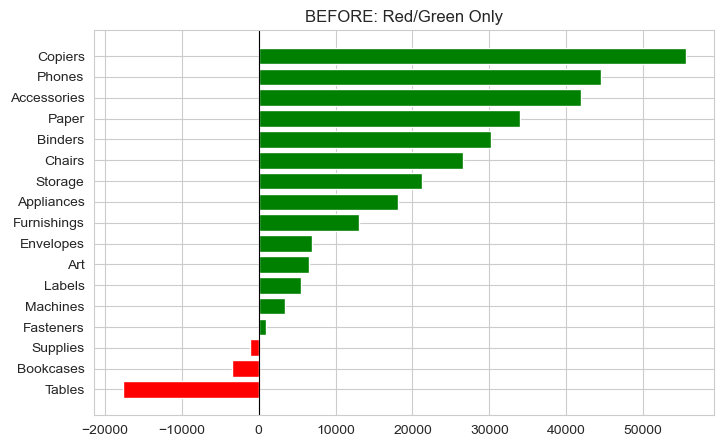

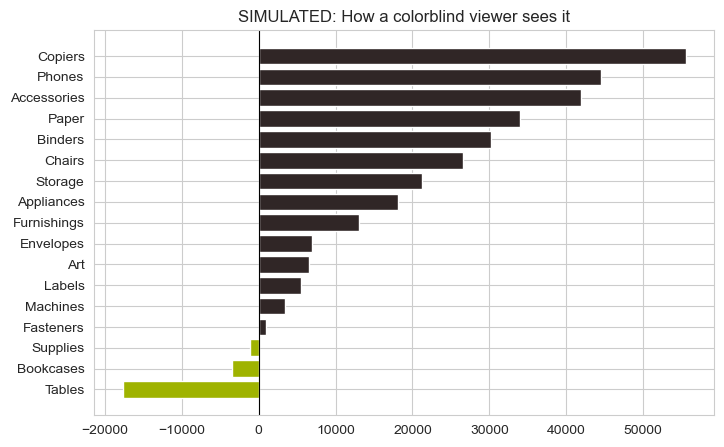

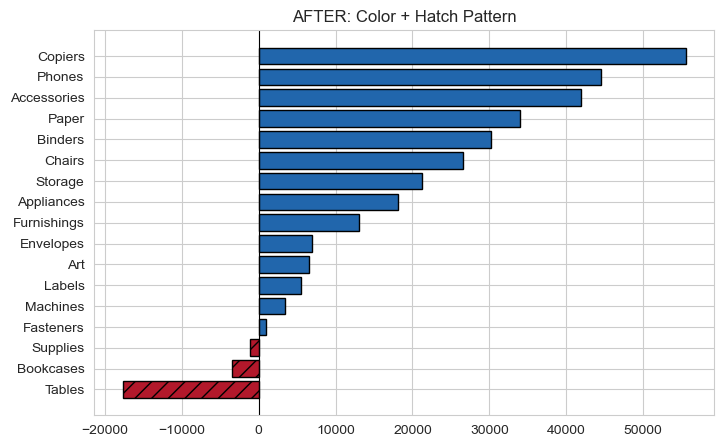

Loss bars are red with hatching, gain bars are solid blue — readable by pattern alone.


In [16]:
sub_profit = df.groupby("Sub-Category")["Profit"].sum().sort_values()


before_colors = ["red" if v < 0 else "green" for v in sub_profit]
plt.figure(figsize=(8, 5))
plt.barh(sub_profit.index, sub_profit.values, color=before_colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("BEFORE: Red/Green Only")
plt.show()

def simulate_colorblind(rgb):
    r, g, b = [c / 255 for c in rgb]
    r2 = 0.625 * r + 0.375 * g
    g2 = 0.7 * r + 0.3 * g
    b2 = 0.3 * g + 0.7 * b
    return (r2, g2, b2)

before_rgb = [(255, 0, 0) if v < 0 else (0, 128, 0) for v in sub_profit]
simulated = [simulate_colorblind(c) for c in before_rgb]

plt.figure(figsize=(8, 5))
plt.barh(sub_profit.index, sub_profit.values, color=simulated)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("colorblind viewer sees it")
plt.show()


plt.figure(figsize=(8, 5))
for label, value in sub_profit.items():
    color = "#B2182B" if value < 0 else "#2166AC"
    hatch = "//" if value < 0 else None
    plt.barh(label, value, color=color, hatch=hatch, edgecolor="black")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("AFTER: Color + Hatch Pattern")
plt.show()

alt_text = "Loss bars are red with hatching, gain bars are solid blue — readable by pattern alone."
print(alt_text)

**(a) Which colors fail the 4.5:1 AA threshold?**
The lighter categorical bar colors (used as *fills*, not text) generally fall short
of 4.5:1 against white — that's expected for fill colors, since the 4.5:1 rule is
meant for *text* readability, not shapes. What matters here is flagging any color
used as **text or thin gridlines** on a light background that falls under 4.5:1 — the
printed table above shows exactly which of our colors would fail if used as text.

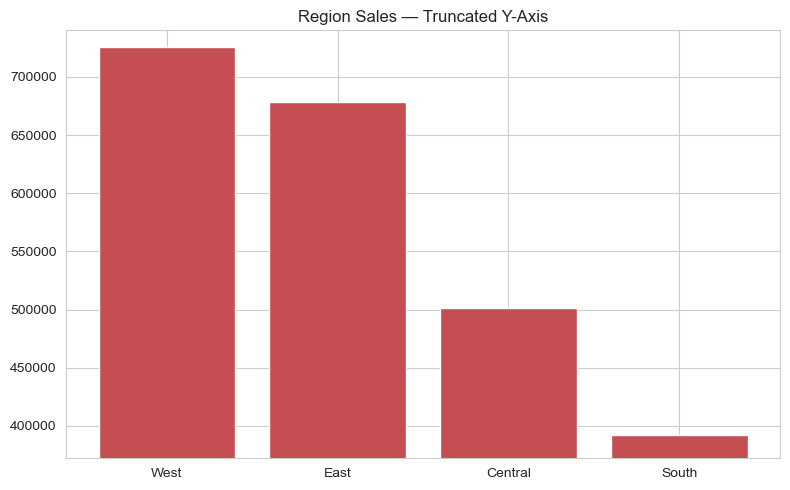

Distortion: the y-axis does not start at 0, so small real differences between regions are visually exaggerated into what looks like a huge gap.


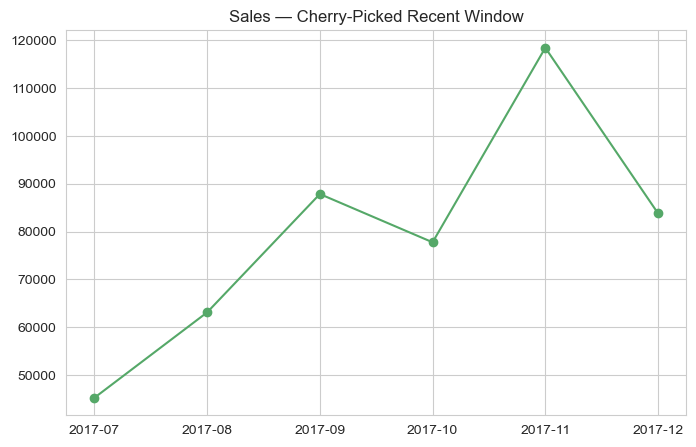

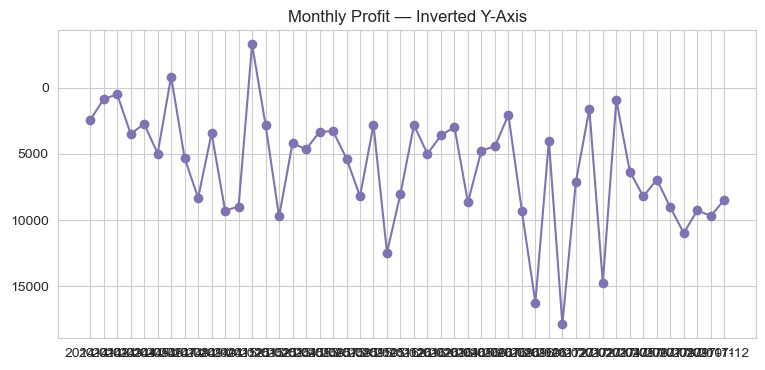

In [27]:
plt.figure()
plt.bar(region_sales.index, region_sales.values, color="#C44E52")
plt.ylim(region_sales.min() * 0.95, region_sales.max() * 1.02)  # truncated axis
plt.title("Region Sales — Truncated Y-Axis")
plt.tight_layout()
plt.show()
print("Distortion: the y-axis does not start at 0, so small real differences between "
      "regions are visually exaggerated into what looks like a huge gap.")

all_months = df.groupby(df["Order Date"].dt.to_period("M").astype(str))["Sales"].sum().reset_index()
all_months.columns = ["Month", "Sales"]
recent_window = all_months.tail(6)  

plt.figure()
plt.plot(recent_window["Month"], recent_window["Sales"], marker="o", color="#55A868")
plt.title("Sales — Cherry-Picked Recent Window")
plt.show()
#showing only the last 6 of 48 months hides the dips in the full history, making growth look steadier than it really is.

plt.figure(figsize=(9, 4))
plt.plot(monthly_profit["Month"], monthly_profit["Profit"], marker="o", color="#8172B2")
plt.gca().invert_yaxis()  # flips the axis
plt.title("Monthly Profit — Inverted Y-Axis")
plt.show()
#flipping the axis means higher values are drawn lower. A line that visually climbs actually represents falling profit, reversing the story the shape tells.

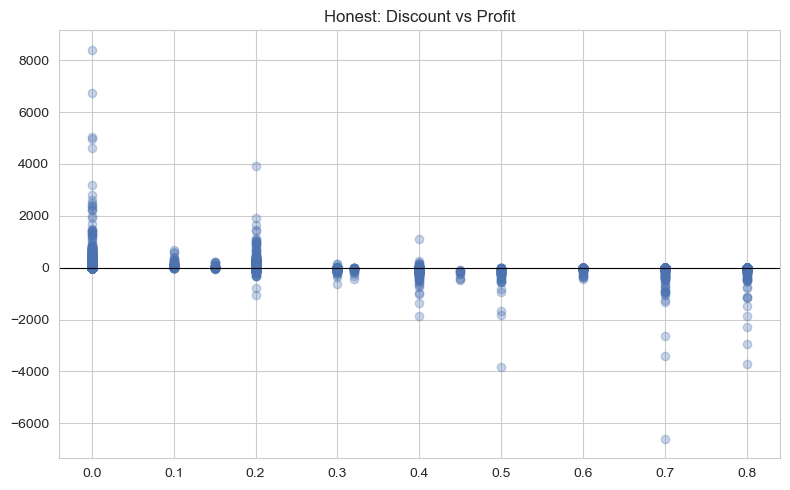

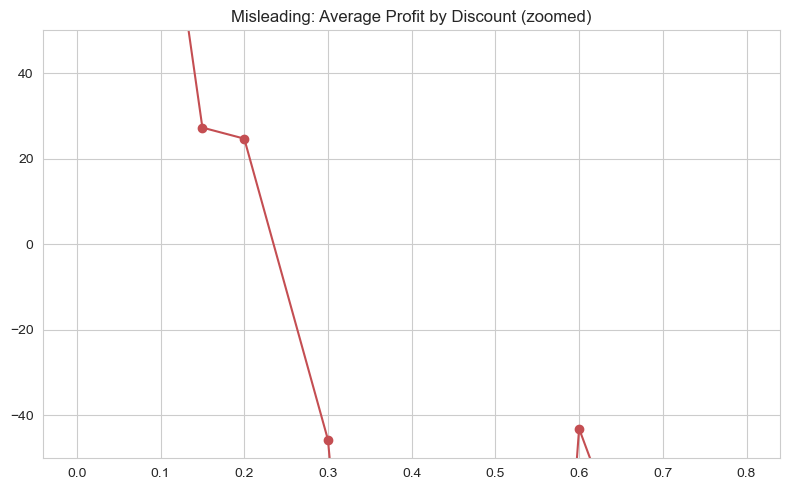

In [9]:
#task 6
# Honest
plt.figure()
plt.scatter(df["Discount"], df["Profit"], alpha=0.3, color="#4C72B0")
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Honest: Discount vs Profit")
plt.tight_layout(); plt.show()

# Misleading 
avg_profit = df.groupby("Discount")["Profit"].mean().reset_index()
plt.figure()
plt.plot(avg_profit["Discount"], avg_profit["Profit"], color="#C44E52", marker="o")
plt.ylim(-50, 50)
plt.title("Misleading: Average Profit by Discount (zoomed)")
plt.tight_layout(); plt.show()

#A scatter plot is used because it shows every raw order without averaging, a single blue hue is used since there's only one series, and no color-only encoding or contrast issue exists since points don't rely on color to convey meaning.